In [46]:
import os
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from copy import deepcopy


from sklearn.inspection import permutation_importance
from sklearn.metrics import recall_score, classification_report
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Removed SMOTE import
from scipy import stats  # For statistical tests
from scipy.stats import f_oneway

import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, LSTM, Input, MultiHeadAttention,GlobalMaxPooling1D,BatchNormalization,Bidirectional,Lambda
from tensorflow.keras.layers import LayerNormalization, GlobalAveragePooling1D, Embedding
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Add
from tensorflow.keras.optimizers import Adam
from collections import Counter
from tensorflow.keras.regularizers import l2

import pickle

import warnings
warnings.filterwarnings('ignore')

In [47]:
# Collecting Training and Testing Dataset File Paths
df2019_train = []
dfps2019_test = []
labels = set()


for dirname, _, filenames in os.walk(r'E:\DACS\DACS\Data\CICDDoS2019'):

    for filename in filenames:
        if filename.endswith('-training.parquet'):
            dfp = os.path.join(dirname, filename)
            df2019_train.append(dfp)
            label = filename.split('-')[0]
            labels.add(label)
            print(dfp)
        elif filename.endswith('-testing.parquet'):
            dfp = os.path.join(dirname, filename)
            dfps2019_test.append(dfp)
            label = filename.split('-')[0]
            labels.add(label)
            print(dfp)

print("Các nhãn (label) tìm thấy trong CICDDos2019:")
for label in sorted(labels):
    print("-", label)


E:\DACS\DACS\Data\CICDDoS2019\DNS-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\LDAP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\LDAP-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\MSSQL-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\MSSQL-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\NetBIOS-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\NetBIOS-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\NTP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Portmap-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\SNMP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Syn-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Syn-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\TFTP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDP-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDPLag-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDPLag-training.parquet
Các nhãn (label) tìm thấy trong CICDDos2019:
- DNS
- LDAP
- MSSQL
- NTP
- NetBIOS
- Portmap
- SNMP
- Syn
- TFTP
- UDP

In [48]:
data_dir = r'E:\DACS\DACS\Data\CICDDoS2017'
labels = set()

df2017 = [] 
for dirname, _, filenames in os.walk(data_dir):
    for filename in filenames:
        if filename.endswith('.parquet'):
            file_path = os.path.join(dirname, filename)
            df2017.append(file_path)
            label = filename.split('-')[0]
            labels.add(label)
            print(file_path)
print("Các nhãn (label) tìm thấy trong CICDDos2017:")
for label in sorted(labels):
    print("-", label)


E:\DACS\DACS\Data\CICDDoS2017\Benign-Monday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Botnet-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Bruteforce-Tuesday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\DDoS-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\DoS-Wednesday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Infiltration-Thursday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Portscan-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\WebAttacks-Thursday-no-metadata.parquet
Các nhãn (label) tìm thấy trong CICDDos2017:
- Benign
- Botnet
- Bruteforce
- DDoS
- DoS
- Infiltration
- Portscan
- WebAttacks


In [49]:
df_2017 = pd.concat([pd.read_parquet(dfp) for dfp in df2017], ignore_index=True)
df_2019 = pd.concat([pd.read_parquet(dfp) for dfp in df2019_train], ignore_index=True)

In [50]:
df = pd.concat([df_2017, df_2019], ignore_index=True)

In [51]:
def label_binary(row):
    return 'Benign' if row == 'Benign' else 'DDoS'
df['Label'] = df['Label'].apply(label_binary)

In [52]:
print(df['Label'].value_counts())

Label
Benign    2023745
DDoS       415235
Name: count, dtype: int64


In [53]:
features_names = [
    'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max',
    'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean',
    'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean',
    'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean',
    'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
    'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
    'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
    'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max',
    'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
    'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
    'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Avg Packet Size',
    'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk',
    'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate',
    'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes',
    'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 'Fwd Act Data Packets', 'Fwd Seg Size Min',
    'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std',
    'Idle Max', 'Idle Min'
]

In [54]:
print("Check features:", features_names)

Check features: ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Cou

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import joblib

df = df.fillna(0)

y_labels = df['Label'].unique()
print('Tất cả nhãn sau khi gộp:', y_labels)

X = df[features_names].astype(np.float32).values
y_binary = (df['Label'] != 'Benign').astype(int).values

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)
print("X_train:", X_train.shape, "y_train:", y_train.shape)

# Fit scaler chỉ trên X_train
scaler = MinMaxScaler()
scaler.fit(X_train)
joblib.dump(scaler, 'scaler_2019.pkl')

# Chuẩn hóa X_train/X_test
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Tất cả nhãn sau khi gộp: ['Benign' 'DDoS']
X_train: (1951184, 77) y_train: (1951184,)


In [56]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print('After oversample:', X_res.shape, y_res.shape)

X_res_scaled = scaler.transform(X_res)

After oversample: (3237992, 77) (3237992,)


In [57]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=2, 
    min_lr=1e-6, 
    verbose=1
)

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_res), y=y_res)
class_weight_dict = dict(zip(np.unique(y_res), class_weights))
print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}


In [58]:
def create_binary_cnn(input_shape):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        Conv1D(32, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        Conv1D(32, kernel_size=3, activation='relu'),
        BatchNormalization(),
        GlobalMaxPooling1D(),
        Dense(32, activation='relu'),
        Dropout(0.15),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Tạo nhãn one-hot (y_train_bin_cat) nếu chưa có:
from tensorflow.keras.utils import to_categorical
y_train_bin_cat = to_categorical(y_res, num_classes=2)

# Reshape input cho CNN
X_train_model = X_res_scaled.reshape(-1, len(features_names), 1)

# Huấn luyện model
cnn_model = create_binary_cnn(X_train_model.shape[1:])
cnn_model.fit(X_train_model, 
              y_train_bin_cat, 
              epochs=15, 
              batch_size=256, 
              validation_split=0.2, 
              class_weight=class_weight_dict,
              callbacks=[early_stop]
              )

# Lưu model
cnn_model.save('CNN_ddos_model.h5')

Epoch 1/15
10119/10119 ━━━━━━━━━━━━━━━━━━━━ 168s 16ms/step - accuracy: 0.9444 - loss: 0.1411 - val_accuracy: 0.9583 - val_loss: 0.0675
Epoch 2/15
10119/10119 ━━━━━━━━━━━━━━━━━━━━ 175s 17ms/step - accuracy: 0.9783 - loss: 0.0510 - val_accuracy: 0.9813 - val_loss: 0.0437
Epoch 3/15
10119/10119 ━━━━━━━━━━━━━━━━━━━━ 177s 18ms/step - accuracy: 0.9826 - loss: 0.0423 - val_accuracy: 0.9867 - val_loss: 0.0331
Epoch 4/15
10119/10119 ━━━━━━━━━━━━━━━━━━━━ 178s 18ms/step - accuracy: 0.9867 - loss: 0.0346 - val_accuracy: 0.9770 - val_loss: 0.0467
Epoch 5/15
10119/10119 ━━━━━━━━━━━━━━━━━━━━ 177s 17ms/step - accuracy: 0.9888 - loss: 0.0304 - val_accuracy: 0.9932 - val_loss: 0.0277
Epoch 6/15
10119/10119 ━━━━━━━━━━━━━━━━━━━━ 151s 15ms/step - accuracy: 0.9896 - loss: 0.0284 - val_accuracy: 0.9911 - val_loss: 0.0259
Epoch 7/15
10119/10119 ━━━━━━━━━━━━━━━━━━━━ 161s 16ms/step - accuracy: 0.9907 - loss: 0.0263 - val_accuracy: 0.9956 - val_loss: 0.0157
Epoch 8/15
10119/10119 ━━━━━━━━━━━━━━━━━━━━ 161s 16ms/s

15244/15244 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step


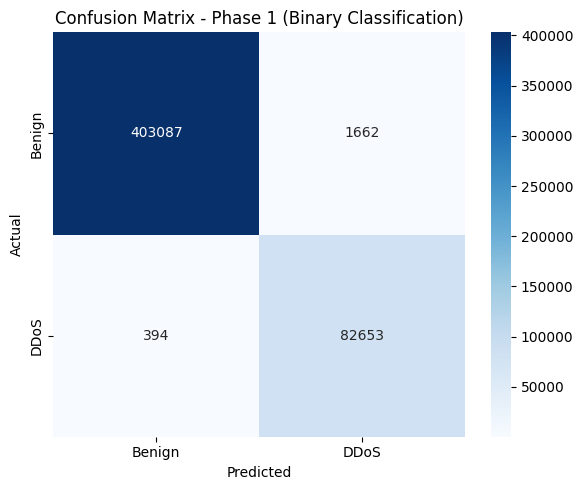

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    404749
        DDoS       0.98      1.00      0.99     83047

    accuracy                           1.00    487796
   macro avg       0.99      1.00      0.99    487796
weighted avg       1.00      1.00      1.00    487796



In [59]:
X_test_model = X_test_scaled.reshape(-1, len(features_names), 1)
y_pred_prob = cnn_model.predict(X_test_model)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Benign', 'DDoS']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Phase 1 (Binary Classification)")
plt.tight_layout()
plt.show()

# Báo cáo chi tiết
print(classification_report(y_test, y_pred, target_names=labels))

In [81]:
# Collecting Training and Testing Dataset File Paths
df2019_train = []
dfps2019_test = []
labels = set()


for dirname, _, filenames in os.walk(r'E:\DACS\DACS\Data\CICDDoS2019'):

    for filename in filenames:
        if filename.endswith('-training.parquet'):
            dfp = os.path.join(dirname, filename)
            df2019_train.append(dfp)
            label = filename.split('-')[0]
            labels.add(label)
            print(dfp)
        elif filename.endswith('-testing.parquet'):
            dfp = os.path.join(dirname, filename)
            dfps2019_test.append(dfp)
            label = filename.split('-')[0]
            labels.add(label)
            print(dfp)

print("Các nhãn (label) tìm thấy trong CICDDos2019:")
for label in sorted(labels):
    print("-", label)


E:\DACS\DACS\Data\CICDDoS2019\DNS-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\LDAP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\LDAP-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\MSSQL-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\MSSQL-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\NetBIOS-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\NetBIOS-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\NTP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Portmap-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\SNMP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Syn-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Syn-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\TFTP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDP-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDPLag-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDPLag-training.parquet
Các nhãn (label) tìm thấy trong CICDDos2019:
- DNS
- LDAP
- MSSQL
- NTP
- NetBIOS
- Portmap
- SNMP
- Syn
- TFTP
- UDP

In [82]:
data_dir = r'E:\DACS\DACS\Data\CICDDoS2017'
labels = set()

df2017 = [] 
for dirname, _, filenames in os.walk(data_dir):
    for filename in filenames:
        if filename.endswith('.parquet'):
            file_path = os.path.join(dirname, filename)
            df2017.append(file_path)
            label = filename.split('-')[0]
            labels.add(label)
            print(file_path)
print("Các nhãn (label) tìm thấy trong CICDDos2017:")
for label in sorted(labels):
    print("-", label)


E:\DACS\DACS\Data\CICDDoS2017\Benign-Monday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Botnet-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Bruteforce-Tuesday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\DDoS-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\DoS-Wednesday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Infiltration-Thursday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Portscan-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\WebAttacks-Thursday-no-metadata.parquet
Các nhãn (label) tìm thấy trong CICDDos2017:
- Benign
- Botnet
- Bruteforce
- DDoS
- DoS
- Infiltration
- Portscan
- WebAttacks


In [90]:
df_2017 = pd.concat([pd.read_parquet(dfp) for dfp in df2017], ignore_index=True)
df_2019 = pd.concat([pd.read_parquet(dfp) for dfp in df2019_train], ignore_index=True)

In [91]:
df = pd.concat([df_2017, df_2019], ignore_index=True)

In [92]:
# Lưu lại nhãn gốc làm cột AttackType (nếu trước đó nhãn gốc là Label)
df['AttackType'] = df['Label']

# Sau đó mới gộp nhãn Label về chỉ Benign/DDoS
def label_binary(row):
    return 'Benign' if row == 'Benign' else 'DDoS'
df['Label'] = df['Label'].apply(label_binary)

print("Label:", df['Label'].unique())
print("AttackType:", df['AttackType'].unique())


Label: ['Benign' 'DDoS']
AttackType: ['Benign' 'Bot' 'FTP-Patator' 'SSH-Patator' 'DDoS' 'DoS slowloris'
 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed' 'Infiltration'
 'PortScan' 'Web Attack � Brute Force' 'Web Attack � XSS'
 'Web Attack � Sql Injection' 'NetBIOS' 'LDAP' 'MSSQL' 'Portmap' 'Syn'
 'UDP' 'UDPLag']


In [96]:
    # Chuẩn hóa AttackType về các nhóm nhỏ hơn cho phase 2
attack_group_map = {
        # DrDoS/Reflection
        'DrDoS_DNS': 'DrDoS',
        'DrDoS_SNMP': 'DrDoS',
        'DrDoS_NTP': 'DrDoS',
        'DrDoS_MSSQL': 'DrDoS',
        'DrDoS_SSDP': 'DrDoS',
        'DrDoS_UDP': 'DrDoS',
        'TFTP': 'TFTP',
        # DDoS truyền thống
        'UDP': 'UDP',
        'UDPLag': 'UDP',
        'Syn': 'Syn',
        'MSSQL': 'MSSQL',
        'LDAP': 'LDAP',
        # DoS - đơn lẻ
        'DoS slowloris': 'DoS',
        'DoS Slowhttptest': 'DoS',
        'DoS Hulk': 'DoS',
        'DoS GoldenEye': 'DoS',
        'Heartbleed': 'Other',
        # Web
        'Web Attack � Brute Force': 'Web Attack',
        'Web Attack � XSS': 'Web Attack',
        'Web Attack � Sql Injection': 'Web Attack',
        # Brute Force & Infiltration
        'FTP-Patator': 'Brute Force',
        'SSH-Patator': 'Brute Force',
        'Infiltration': 'Other',
        'Bot': 'Other',
        # PortScan
        'PortScan': 'PortScan',
        # NetBIOS
        'NetBIOS': 'Other',
        # Other (các loại còn lại)
    }

def group_attack_type(x):
        if x == 'Benign':
            return 'Benign'
        return attack_group_map.get(x, 'Other')

df['AttackType'] = df['AttackType'].apply(group_attack_type)

print("Các nhóm attack sau khi chuẩn hóa:", df['AttackType'].unique())
print(df['AttackType'].value_counts())

Các nhóm attack sau khi chuẩn hóa: ['Benign' 'Other' 'Brute Force' 'DoS' 'PortScan' 'Web Attack' 'LDAP'
 'MSSQL' 'Syn' 'UDP']
AttackType
Benign         2023745
DoS             193745
Other           130827
Syn              48840
UDP              18145
Brute Force       9150
MSSQL             8523
Web Attack        2143
PortScan          1956
LDAP              1906
Name: count, dtype: int64


In [97]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical


# Chỉ lấy DDoS
df_attack = df[df['Label'] == 'DDoS'].copy()
X_attack = df_attack[features_names].astype(np.float32).values
y_attack = df_attack['AttackType'].values

# Encode
label_encoder = LabelEncoder()
y_attack_encoded = label_encoder.fit_transform(y_attack)
joblib.dump(label_encoder, "attack_label_encoder.pkl")
y_attack_cat = to_categorical(y_attack_encoded)
n_classes = len(label_encoder.classes_)
print("Các lớp attack:", label_encoder.classes_)

Các lớp attack: ['Brute Force' 'DoS' 'LDAP' 'MSSQL' 'Other' 'PortScan' 'Syn' 'UDP'
 'Web Attack']


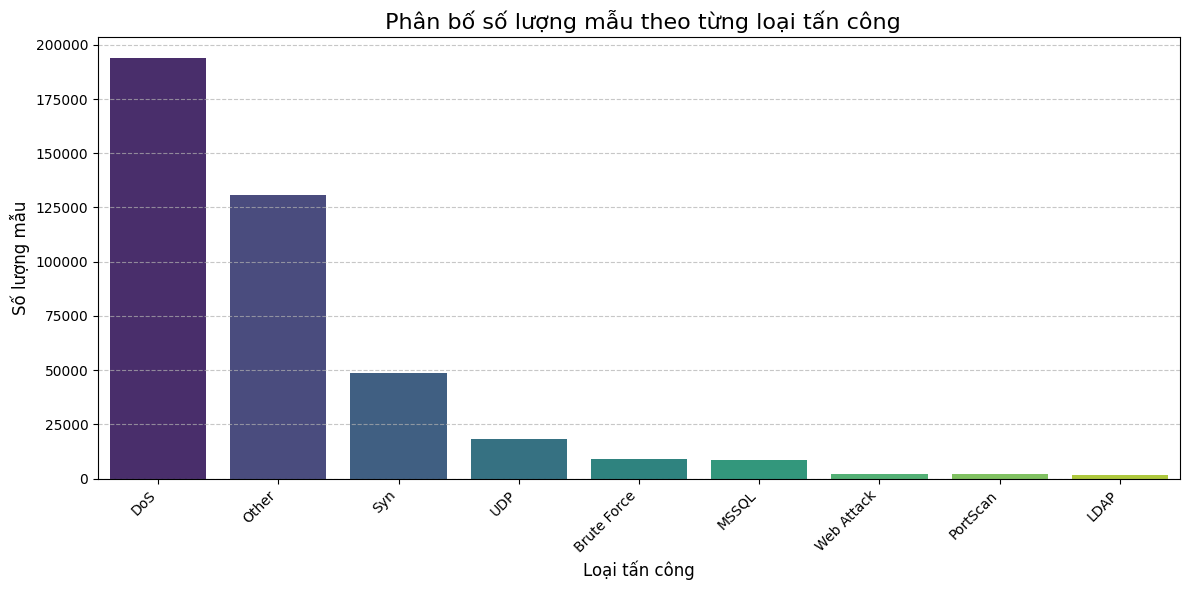

In [114]:
# Đếm số lượng mỗi lớp tấn công
attack_counts = pd.Series(y_attack).value_counts().sort_values(ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.barplot(x=attack_counts.index, y=attack_counts.values, palette="viridis")

plt.title(" Phân bố số lượng mẫu theo từng loại tấn công", fontsize=16)
plt.xlabel("Loại tấn công", fontsize=12)
plt.ylabel("Số lượng mẫu", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

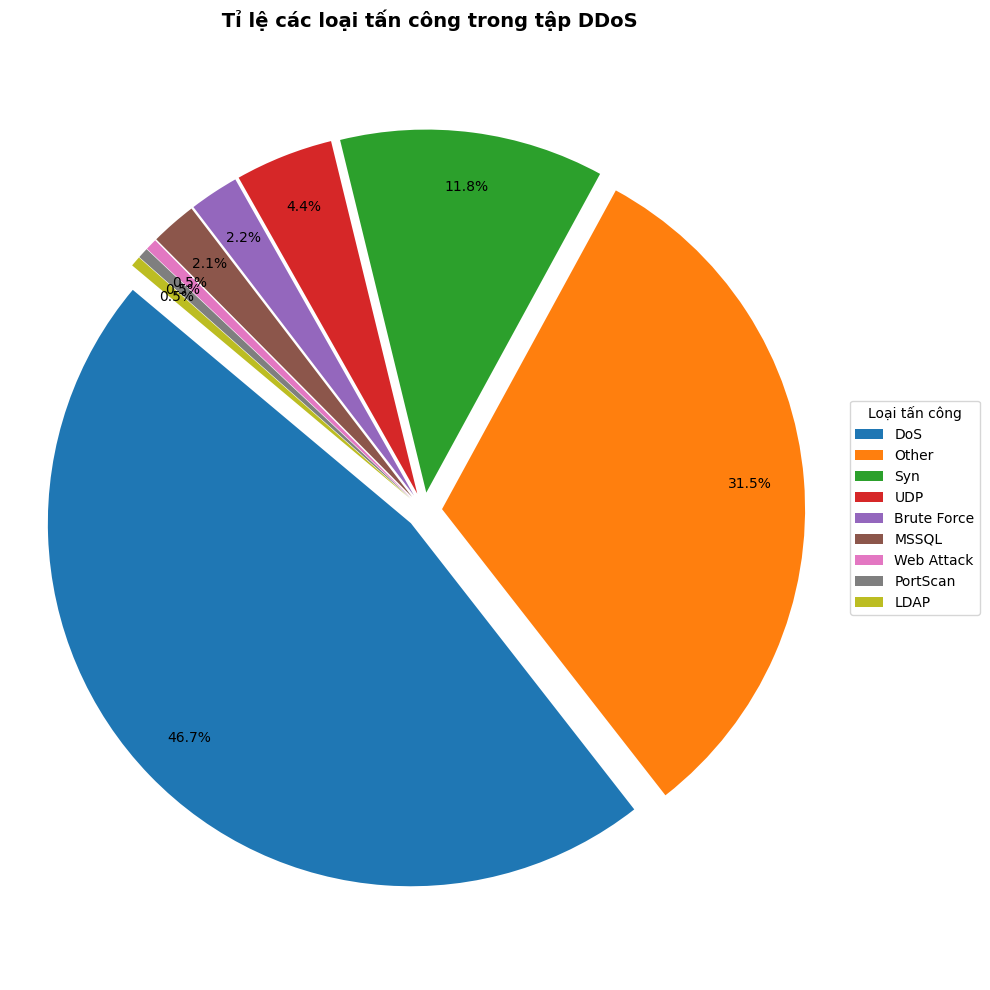

In [99]:
import matplotlib.pyplot as plt
import pandas as pd

# Phân bố attack
attack_distribution = pd.Series(y_attack).value_counts()

# Các tham số tách từng phần ra một chút để tránh đè
explode = [0.05] * len(attack_distribution)

# Vẽ Pie Chart
fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    attack_distribution.values,
    labels=None,  # Không chèn nhãn vào trong pie
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    pctdistance=0.85,       # Đẩy % ra xa hơn
    labeldistance=1.1,      # Đẩy nhãn (nếu dùng) ra ngoài
    textprops={'fontsize': 10}
)

# Chú thích ngoài
ax.legend(
    wedges,
    attack_distribution.index,
    title="Loại tấn công",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10
)

plt.title(" Tỉ lệ các loại tấn công trong tập DDoS", fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()


In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_attack_res, y_attack_res = sm.fit_resample(X_attack, y_attack_encoded)

y_attack_cat = to_categorical(y_attack_res)

print("Số lượng mẫu sau khi oversample:", len(y_attack_res))



After oversample: (1743705, 77) (1743705,)
Số lượng mẫu sau khi oversample: 1743705


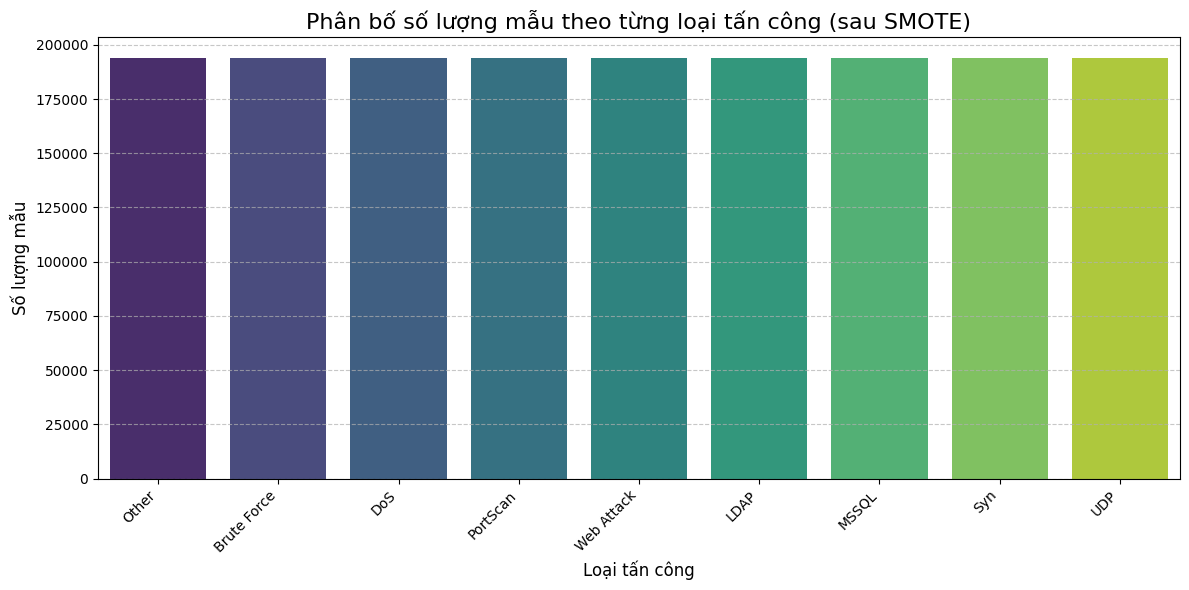

In [116]:
# Nếu đã label encode, giải mã tên lớp
try:
    attack_labels_after = label_encoder.inverse_transform(y_attack_res)
except:
    attack_labels_after = y_attack_res

attack_counts_after = pd.Series(attack_labels_after).value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=attack_counts_after.index, y=attack_counts_after.values, palette="viridis")

plt.title("Phân bố số lượng mẫu theo từng loại tấn công (sau SMOTE)", fontsize=16)
plt.xlabel("Loại tấn công", fontsize=12)
plt.ylabel("Số lượng mẫu", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



In [103]:
X_attack_scaled_res = scaler.transform(X_attack_res)
X_attack_scaled_cnn_res = X_attack_scaled_res.reshape(-1, len(features_names), 1)


def create_multiclass_cnn(input_shape, num_classes):
    model = Sequential([
        Conv1D(128, kernel_size=5, activation='relu', input_shape=input_shape, kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Conv1D(32, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        GlobalMaxPooling1D(),
        Dropout(0.5),
        Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model
multiclass_cnn = create_multiclass_cnn(X_attack_scaled_cnn_res.shape[1:], n_classes)
history = multiclass_cnn.fit(
    X_attack_scaled_cnn_res, y_attack_cat,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

# Lưu model
multiclass_cnn.save('attack_classifier.h5')

Epoch 1/30
87186/87186 ━━━━━━━━━━━━━━━━━━━━ 662s 8ms/step - accuracy: 0.8730 - loss: 0.4208 - val_accuracy: 0.8848 - val_loss: 0.5447 - learning_rate: 5.0000e-04
Epoch 2/30
87186/87186 ━━━━━━━━━━━━━━━━━━━━ 802s 9ms/step - accuracy: 0.9671 - loss: 0.1351 - val_accuracy: 0.7661 - val_loss: 0.8087 - learning_rate: 5.0000e-04
Epoch 3/30
87182/87186 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9698 - loss: 0.1227
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
87186/87186 ━━━━━━━━━━━━━━━━━━━━ 717s 8ms/step - accuracy: 0.9698 - loss: 0.1227 - val_accuracy: 0.8948 - val_loss: 0.5810 - learning_rate: 5.0000e-04
Epoch 4/30
87186/87186 ━━━━━━━━━━━━━━━━━━━━ 532s 6ms/step - accuracy: 0.9739 - loss: 0.1037 - val_accuracy: 0.9073 - val_loss: 0.4551 - learning_rate: 2.5000e-04
Epoch 5/30
87186/87186 ━━━━━━━━━━━━━━━━━━━━ 430s 5ms/step - accuracy: 0.9749 - loss: 0.0979 - val_accuracy: 0.9072 - val_loss: 0.4419 - learning_rate: 2.5000e-04
Epoch 6/30
87186/87186 ━━━━━━━━━━━━

In [105]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['Label'], random_state=42)

In [106]:
# Chỉ lấy DDoS trong tập test
df_attack_test = test_df[test_df['Label'] == 'DDoS'].copy()
X_attack_test = df_attack_test[features_names].astype(np.float32).values
y_attack_test = df_attack_test['AttackType'].values

# Encode label (dùng lại label_encoder đã fit từ train!)
y_attack_test_encoded = label_encoder.transform(y_attack_test)

In [107]:
X_attack_test_scaled = scaler.transform(X_attack_test)
X_attack_test_scaled_cnn = X_attack_test_scaled.reshape(-1, len(features_names), 1)


2596/2596 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step


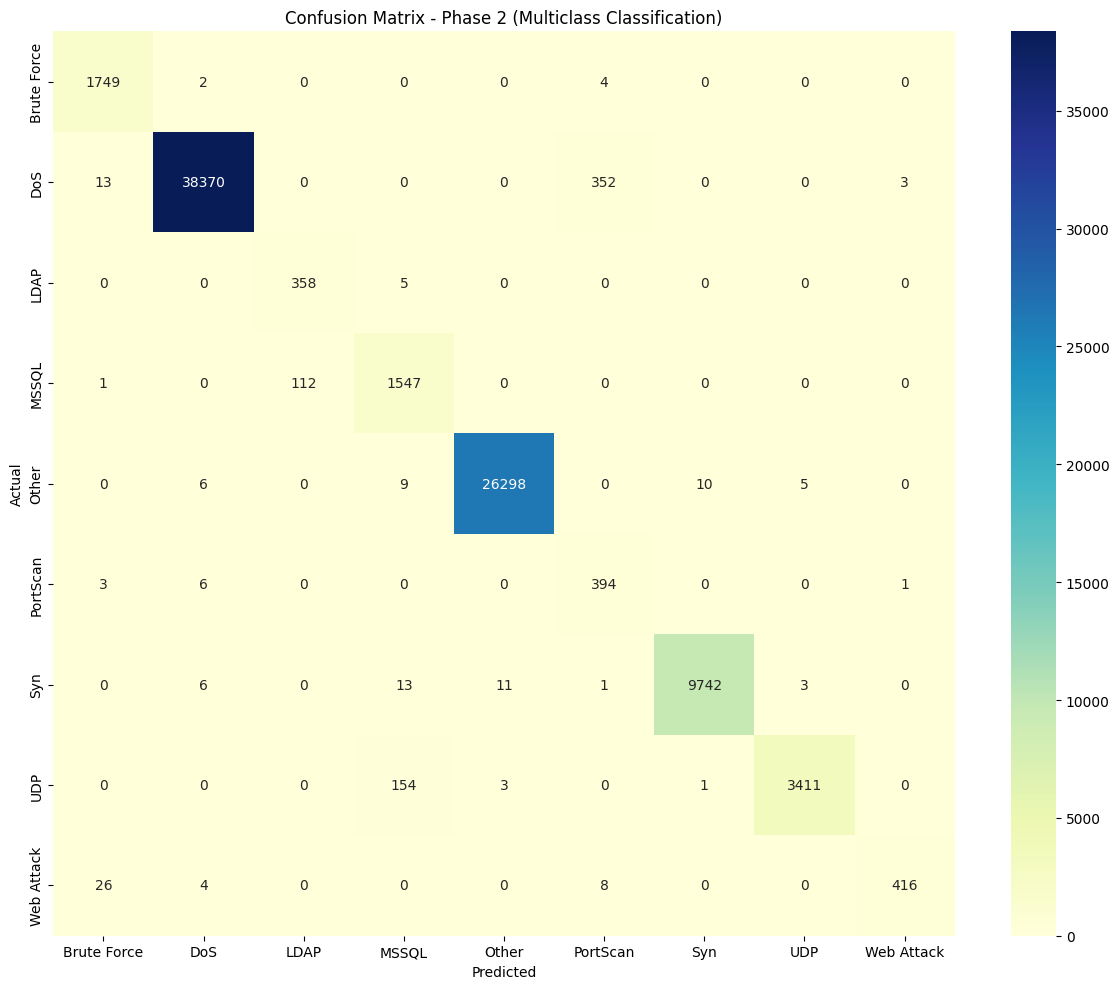

              precision    recall  f1-score   support

 Brute Force       0.98      1.00      0.99      1755
         DoS       1.00      0.99      0.99     38738
        LDAP       0.76      0.99      0.86       363
       MSSQL       0.90      0.93      0.91      1660
       Other       1.00      1.00      1.00     26328
    PortScan       0.52      0.98      0.68       404
         Syn       1.00      1.00      1.00      9776
         UDP       1.00      0.96      0.98      3569
  Web Attack       0.99      0.92      0.95       454

    accuracy                           0.99     83047
   macro avg       0.90      0.97      0.93     83047
weighted avg       0.99      0.99      0.99     83047



In [ ]:
# Dự đoán lại trên toàn bộ attack samples
y_attack_test_pred_prob = multiclass_cnn.predict(X_attack_test_scaled_cnn)
y_attack_test_pred = np.argmax(y_attack_test_pred_prob, axis=1)

from sklearn.metrics import confusion_matrix, classification_report

cm_multi = confusion_matrix(y_attack_test_encoded, y_attack_test_pred)
labels_multi = label_encoder.classes_

plt.figure(figsize=(12, 10))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='YlGnBu', xticklabels=labels_multi, yticklabels=labels_multi)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Phase 2 (Multiclass Classification)")
plt.tight_layout()
plt.show()

# Báo cáo chi tiết
print(classification_report(y_attack_test_encoded, y_attack_test_pred, target_names=labels_multi))


In [124]:
from sklearn.metrics import classification_report
import pandas as pd

# Tạo báo cáo
report = classification_report(
    y_attack_test_encoded, 
    y_attack_test_pred, 
    target_names=labels_multi, 
    output_dict=True
)
df_report = pd.DataFrame(report).transpose()
df_report_main = df_report.iloc[:len(labels_multi), :4].round(2)

# Đổi tên cột sang tiếng Việt
df_report_main.rename(columns={
    'precision': 'Độ chính xác',
    'recall': 'Độ bao phủ',
    'f1-score': 'F1',
    'support': 'Số mẫu'
}, inplace=True)

# Xuất ra file Excel
df_report_main.to_excel("bang_phan_loai_ddos.xlsx", index=True)




In [118]:
with open("classification_report.html", "w", encoding="utf-8") as f:
    f.write(df_report_main.to_html(border=1))